In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Cleaned_Dataset.xlsx")

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9551 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [5]:
#check unique value
df["Has Online delivery"].unique()

array(['No', 'Yes'], dtype=object)

In [7]:
#Percentage of Restaurants Offering Table Booking
table_booking = df["Has Table booking"].value_counts()
table_booking_percent = (table_booking / len(df)) * 100
print(table_booking_percent)

Has Table booking
No     87.875615
Yes    12.124385
Name: count, dtype: float64


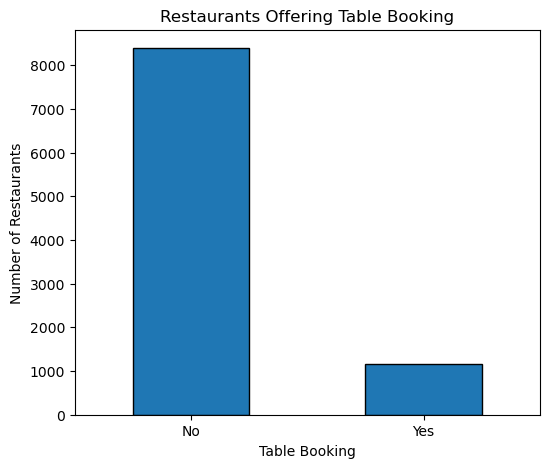

In [ ]:
#Visualize Table Booking
plt.figure(figsize=(6,5))

table_booking.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Restaurants Offering Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

plt.show()

In [10]:
#Percentage of Restaurants Offering Online Delivery
online_delivery = df["Has Online delivery"].value_counts()
online_delivery_percent = (online_delivery / len(df)) * 100
print(online_delivery_percent)

Has Online delivery
No     74.337766
Yes    25.662234
Name: count, dtype: float64


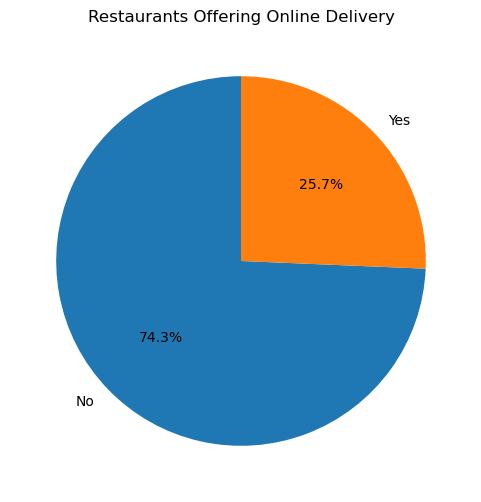

In [13]:
#Visualize Online Delivery
plt.figure(figsize=(6,6))
plt.pie(
    online_delivery_percent,
    labels=online_delivery_percent.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Restaurants Offering Online Delivery")
plt.show()

In [15]:
#Compare Average Ratings
table_booking_rating = df.groupby("Has Table booking")["Aggregate rating"].mean()
print(table_booking_rating)

Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64


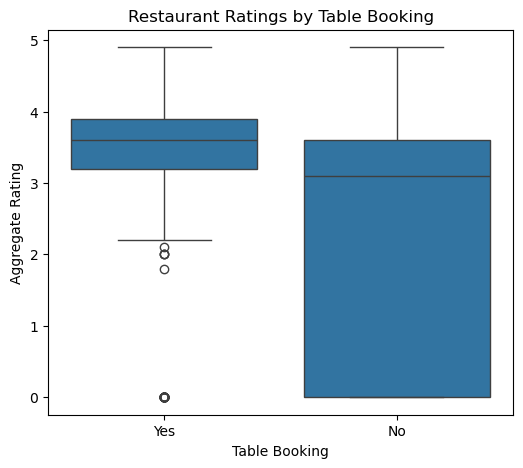

In [19]:
#Visualize the Average Ratings


plt.figure(figsize=(6,5))

sns.boxplot(
    x="Has Table booking",
    y="Aggregate rating",
    data=df
)

plt.title("Restaurant Ratings by Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Aggregate Rating")

plt.show()

In [17]:
#Compare Average Ratings (Online Delivery)
online_delivery_rating = df.groupby("Has Online delivery")["Aggregate rating"].mean()

print(online_delivery_rating)

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


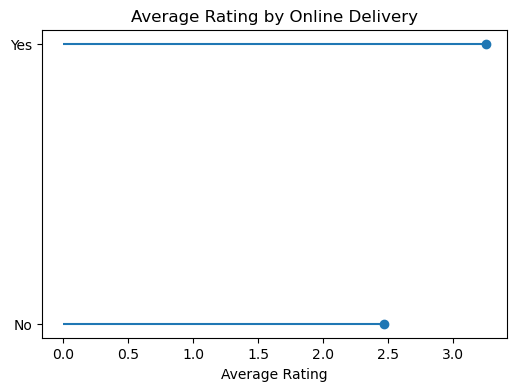

In [ ]:

plt.figure(figsize=(6,4))

plt.hlines(
    y=online_delivery_rating.index,
    xmin=0,
    xmax=online_delivery_rating.values
)

plt.plot(
    online_delivery_rating.values,
    online_delivery_rating.index,
    "o"
)

plt.title("Average Rating by Online Delivery")
plt.xlabel("Average Rating")

plt.show()

# Observations

- The percentage of restaurants offering table booking and online delivery was calculated.
- Most restaurants do not provide table booking, while a smaller percentage offer this service.
- Restaurants with table booking generally have a higher average aggregate rating than those without table booking.
- The comparison of online delivery shows whether restaurants offering this service have higher average ratings than those that do not.
- These findings suggest that customer services such as table booking and online delivery may influence customer satisfaction, although further analysis would be needed to establish a causal relationship.

# Level 2 - Task 2
## Price Range Analysis

In [22]:
# Check the Price Range Values
price_counts = df["Price range"].value_counts().sort_index()
print(price_counts)

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


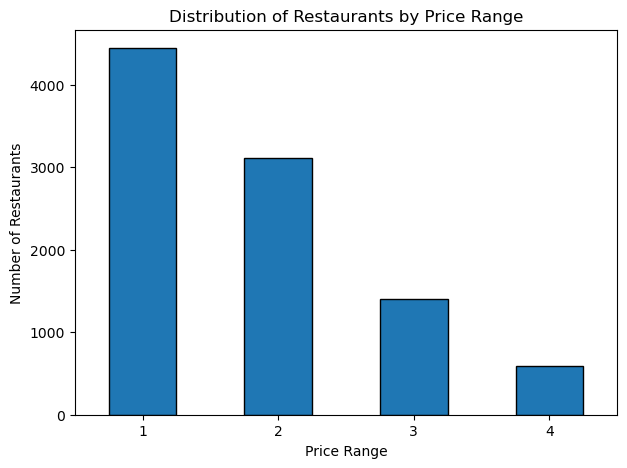

In [23]:
plt.figure(figsize=(7,5))

price_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

plt.show()

In [24]:
#Find the Most Common Price Range
most_common = df["Price range"].mode()[0]

print("Most Common Price Range:", most_common)

Most Common Price Range: 1


In [26]:
#Calculate the Average Rating for Each Price Range
price_rating = df.groupby("Price range")["Aggregate rating"].mean()

print(price_rating)

Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


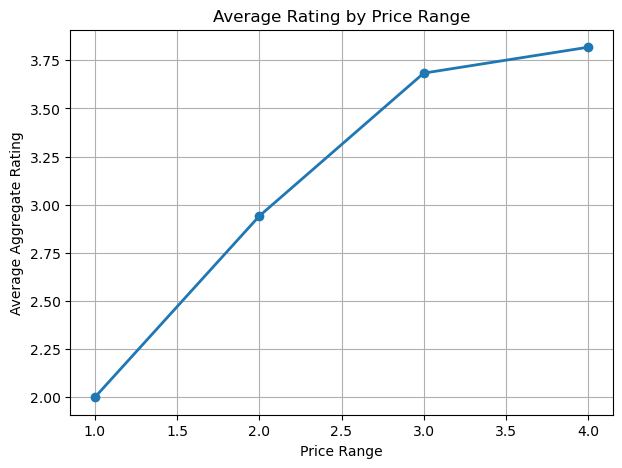

In [27]:
#Visualize the Relationship
plt.figure(figsize=(7,5))

plt.plot(
    price_rating.index,
    price_rating.values,
    marker="o",
    linewidth=2
)

plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Aggregate Rating")

plt.grid(True)

plt.show()


# Observations

- The distribution of restaurants across different price ranges was analyzed.
- The most common price range was identified using the mode of the `Price range` column.
- The average aggregate rating was calculated for each price range.
- The line chart shows how restaurant ratings vary across different price ranges.
- This analysis helps determine whether more expensive restaurants tend to receive higher customer ratings.

# Level 2 - Task 3
## Feature Engineering

In [28]:
#View the Existing Columns
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [29]:
#Restaurant Name Length
df["Restaurant Name Length"] = df["Restaurant Name"].str.len()
df[["Restaurant Name", "Restaurant Name Length"]].head()

,Restaurant Name,Restaurant Name Length
0,Le Petit Souffle,16.0
1,Izakaya Kikufuji,16.0
2,Heat - Edsa Shangri-La,22.0
3,Ooma,4.0
4,Sambo Kojin,11.0


In [30]:
#Cuisine Count
df["Cuisine Count"] = df["Cuisines"].str.split(",").str.len()

df[["Cuisines", "Cuisine Count"]].head()


,Cuisines,Cuisine Count
0,"French, Japanese, Desserts",3
1,Japanese,1
2,"Seafood, Asian, Filipino, Indian",4
3,"Japanese, Sushi",2
4,"Japanese, Korean",2


In [31]:
#Expensive Restaurant
df["Expensive Restaurant"] = df["Price range"].apply(
    lambda x: "Yes" if x >= 3 else "No"
)

df[["Price range", "Expensive Restaurant"]].head()

,Price range,Expensive Restaurant
0,3,Yes
1,3,Yes
2,4,Yes
3,4,Yes
4,4,Yes


In [32]:
#check the new Features
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Restaurant Name Length,Cuisine Count,Expensive Restaurant
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,No,No,3,4.8,Dark Green,Excellent,314,16.0,3,Yes
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,No,No,3,4.5,Dark Green,Excellent,591,16.0,1,Yes
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,No,No,4,4.4,Green,Very Good,270,22.0,4,Yes
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,4,4.9,Dark Green,Excellent,365,4.0,2,Yes
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,No,No,4,4.8,Dark Green,Excellent,229,11.0,2,Yes


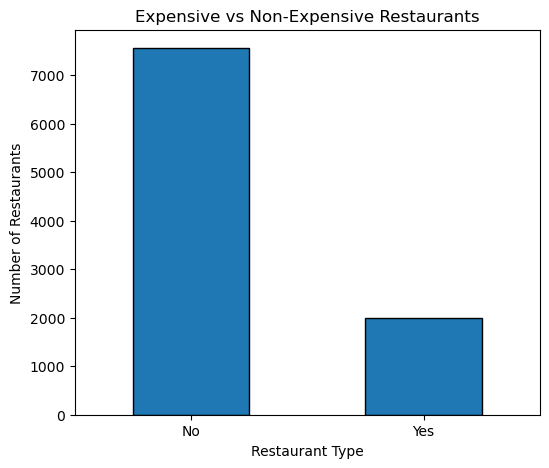

In [33]:
expensive_counts = df["Expensive Restaurant"].value_counts()

plt.figure(figsize=(6,5))

expensive_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Expensive vs Non-Expensive Restaurants")
plt.xlabel("Restaurant Type")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

plt.show()

# Observations

- Three new features were created from the existing dataset.
- **Restaurant Name Length** measures the length of each restaurant's name.
- **Cuisine Count** indicates how many cuisines each restaurant serves.
- **Expensive Restaurant** classifies restaurants based on their price range.
- These engineered features can be useful for future data analysis and machine learning models.